In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = Path(r"C:\Users\aduak\Downloads\capstone")
CLEAN_DIR = DATA_DIR / "cleaned"

cweeds = pd.read_csv(
    CLEAN_DIR / "clean_cweeds_4cities.csv",
    parse_dates=["timestamp"],
    low_memory=False
)

sait_hourly = pd.read_csv(
    CLEAN_DIR / "sait_hourly_valid.csv",
    parse_dates=["timestamp"]
)

print("CWEEDS:", cweeds.shape)
print("SAIT valid hourly:", sait_hourly.shape)

CWEEDS: (701280, 64)
SAIT valid hourly: (13423, 12)


In [6]:
print("CWEEDS date range:")
print(cweeds["timestamp"].min(), "to", cweeds["timestamp"].max())

print("\nCities:")
print(cweeds["city"].value_counts())

print("\nSAIT date range:")
print(sait_hourly["timestamp"].min(), "to", sait_hourly["timestamp"].max())

CWEEDS date range:
1998-01-01 00:00:00 to 2017-12-31 23:00:00

Cities:
city
Calgary         175320
Edmonton        175320
Lethbridge      175320
Medicine Hat    175320
Name: count, dtype: int64

SAIT date range:
2019-03-08 20:00:00 to 2023-09-19 08:00:00


In [7]:
eda_variables = [
    "ghi_wh_m2",
    "dni_wh_m2",
    "dhi_wh_m2",
    "dry_bulb_temp_c",
    "dew_point_temp_c",
    "wind_speed_ms",
    "station_pressure_pa"
]

city_descriptive_stats = (
    cweeds
    .groupby("city")[eda_variables]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

display(city_descriptive_stats)

ghi_wh_m2                             dni_wh_m2                              dhi_wh_m2                            dry_bulb_temp_c                           dew_point_temp_c         \
                  mean median     std  min     max      mean median     std  min      max      mean median    std  min     max            mean median    std   min   max             mean median   
city                                                                                                                                                                                               
Calgary         150.77   3.61  230.58  0.0  972.22    187.67    0.0  306.52  0.0  1022.78     59.22   2.22  88.16  0.0  532.22            4.84    5.6  11.18 -34.6  34.0            -2.77   -2.7   
Edmonton        142.57   1.94  221.34  0.0  952.50    174.09    0.0  290.43  0.0  1010.00     58.73   1.39  86.97  0.0  423.89            2.85    3.4  12.51 -46.1  35.6            -2.68   -2.0   
Lethbridge      159.28   3.61  242.45  0.0  976.67    196.52    0.0  314.37  0.0  1030.56     58.69   2.50  86.05  0.0  448.33            6.76    7.5  11.47 -35.7  37.9            -1.39   -1.0   
Medicine Hat    157.29   1.67  239.90  0.0  974.72    191.35    0.0  308.12  0.0  1028.33     59.27   1.39  86.57  0.0  667.22            6.26    6.8  12.51 -37.6  38.4            -1.56   -0.9   

                                wind_speed_ms                         station_pressure_pa                                 
                std   min   max          mean median   std  min   max                mean   median     std    min    max  
city                                                                                                                      
Calgary        9.33 -39.8  24.0          3.89    3.6  2.55  0.0  21.7            88907.03  88960.0  708.98  85610  91420  
Edmonton      10.99 -46.8  25.3          3.55    3.1  2.22  0.0  20.3            92897.14  92930.0  763.16  89220  96040  
Lethbridge     8.99 -39.9  22.3          4.48    3.6  2.89  0.0  22.2            90902.76  90930.0  688.99  87770  93780  
Medicine Hat   9.44 -42.6  20.9          3.68    3.1  2.46  0.0  23.1            93011.83  93020.0  746.20  89620  96750

In [8]:
solar_city_summary = (
    cweeds
    .groupby("city")
    .agg(
        mean_ghi=("ghi_wh_m2", "mean"),
        median_ghi=("ghi_wh_m2", "median"),
        max_ghi=("ghi_wh_m2", "max"),

        mean_dni=("dni_wh_m2", "mean"),
        mean_dhi=("dhi_wh_m2", "mean"),

        mean_temp_c=("dry_bulb_temp_c", "mean"),
        mean_wind_ms=("wind_speed_ms", "mean")
    )
    .round(2)
    .reset_index()
)

display(solar_city_summary)

,city,mean_ghi,median_ghi,max_ghi,mean_dni,mean_dhi,mean_temp_c,mean_wind_ms
0,Calgary,150.77,3.61,972.22,187.67,59.22,4.84,3.89
1,Edmonton,142.57,1.94,952.50,174.09,58.73,2.85,3.55
2,Lethbridge,159.28,3.61,976.67,196.52,58.69,6.76,4.48
3,Medicine Hat,157.29,1.67,974.72,191.35,59.27,6.26,3.68


In [9]:
daylight = cweeds[cweeds["ghi_wh_m2"] > 0].copy()

daylight_summary = (
    daylight
    .groupby("city")
    .agg(
        daylight_hours=("timestamp", "size"),
        mean_daylight_ghi=("ghi_wh_m2", "mean"),
        median_daylight_ghi=("ghi_wh_m2", "median"),
        mean_daylight_dni=("dni_wh_m2", "mean"),
        mean_daylight_dhi=("dhi_wh_m2", "mean")
    )
    .round(2)
    .reset_index()
)

display(daylight_summary)

,city,daylight_hours,mean_daylight_ghi,median_daylight_ghi,mean_daylight_dni,mean_daylight_dhi
0,Calgary,91066,290.26,222.50,361.30,114.00
1,Edmonton,90560,276.01,204.44,337.04,113.70
2,Lethbridge,90733,307.77,236.94,379.74,113.41
3,Medicine Hat,89836,306.96,235.97,373.43,115.67


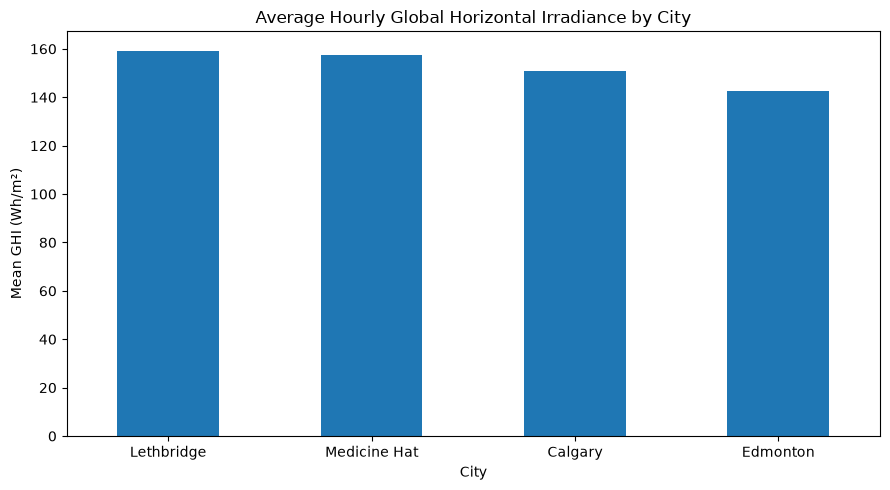

In [10]:
city_ghi_plot = (
    cweeds
    .groupby("city")["ghi_wh_m2"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
city_ghi_plot.plot(kind="bar")

plt.title("Average Hourly Global Horizontal Irradiance by City")
plt.xlabel("City")
plt.ylabel("Mean GHI (Wh/m²)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

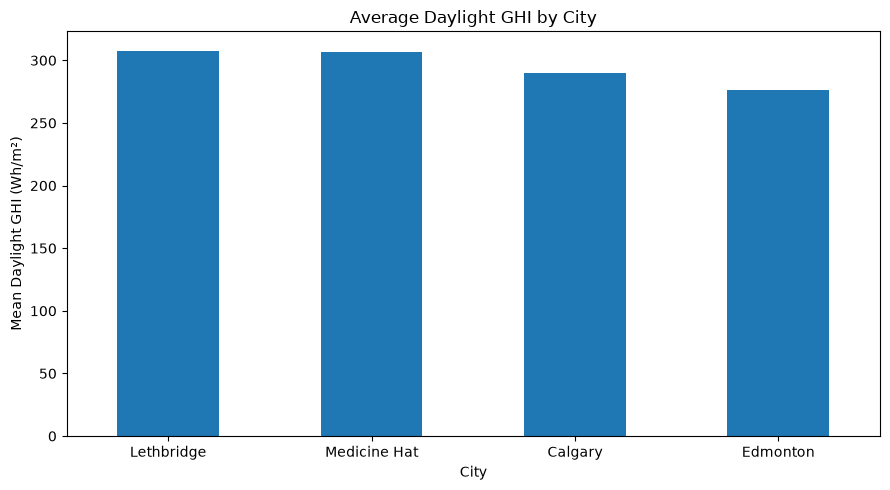

In [11]:
daylight_ghi_plot = (
    daylight
    .groupby("city")["ghi_wh_m2"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
daylight_ghi_plot.plot(kind="bar")

plt.title("Average Daylight GHI by City")
plt.xlabel("City")
plt.ylabel("Mean Daylight GHI (Wh/m²)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
city_comparison = solar_city_summary[
    ["city", "mean_ghi"]
].copy()

edmonton_mean = city_comparison.loc[
    city_comparison["city"] == "Edmonton",
    "mean_ghi"
].iloc[0]

city_comparison["percent_above_edmonton"] = (
    (city_comparison["mean_ghi"] - edmonton_mean)
    / edmonton_mean
    * 100
).round(2)

display(city_comparison.sort_values(
    "mean_ghi",
    ascending=False
))

,city,mean_ghi,percent_above_edmonton
2,Lethbridge,159.28,11.72
3,Medicine Hat,157.29,10.32
0,Calgary,150.77,5.75
1,Edmonton,142.57,0.00


In [13]:
cweeds["month"] = cweeds["timestamp"].dt.month

season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
}

cweeds["season"] = cweeds["month"].map(season_map)

In [14]:
monthly_ghi = (
    cweeds
    .groupby(["city", "month"])["ghi_wh_m2"]
    .mean()
    .reset_index()
)

display(monthly_ghi.head(20))

,city,month,ghi_wh_m2
0,Calgary,1,49.974108
1,Calgary,2,88.756330
2,Calgary,3,140.589736
3,Calgary,4,198.242612
4,Calgary,5,237.979764
5,Calgary,6,248.080131
6,Calgary,7,266.414576
7,Calgary,8,219.484300
8,Calgary,9,159.043152
9,Calgary,10,99.865666


In [15]:
monthly_ghi_pivot = (
    monthly_ghi
    .pivot(
        index="city",
        columns="month",
        values="ghi_wh_m2"
    )
    .round(2)
)

display(monthly_ghi_pivot)

month,1,2,3,4,5,6,7,8,9,10,11,12
city,,,,,,,,,,,,
Calgary,49.97,88.76,140.59,198.24,237.98,248.08,266.41,219.48,159.04,99.87,56.93,40.27
Edmonton,40.26,76.72,131.07,191.71,240.11,248.86,254.33,213.12,147.36,85.99,46.15,31.41
Lethbridge,53.40,91.86,144.13,205.42,246.61,265.05,286.97,234.15,169.58,106.10,60.60,43.57
Medicine Hat,51.70,88.77,142.52,202.92,243.68,261.22,287.42,233.60,167.13,103.02,58.50,42.85


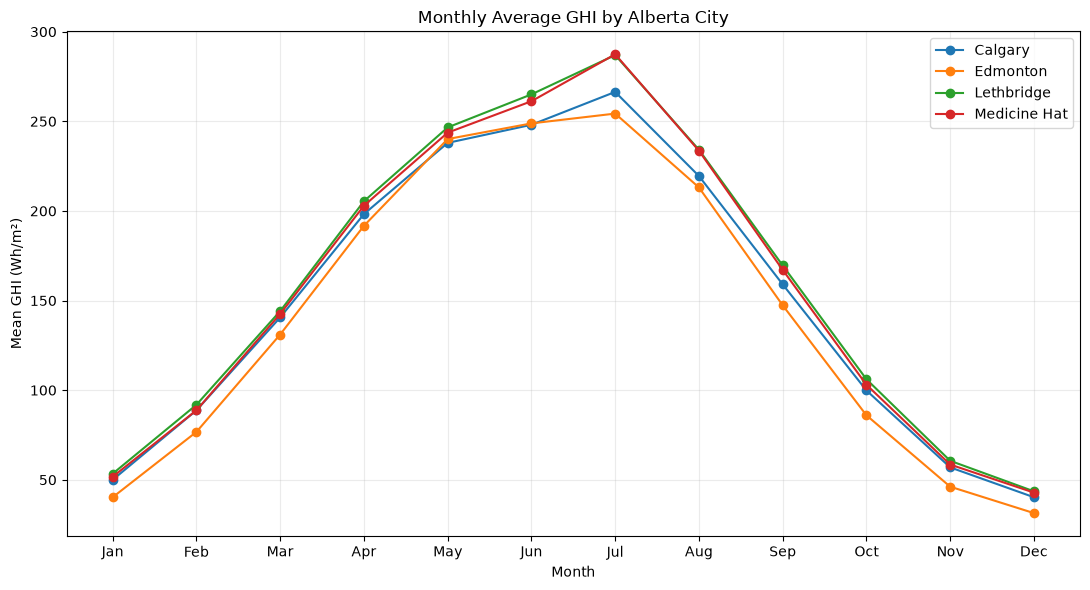

In [16]:
plt.figure(figsize=(11, 6))

for city in monthly_ghi["city"].unique():
    city_monthly = monthly_ghi[
        monthly_ghi["city"] == city
    ]

    plt.plot(
        city_monthly["month"],
        city_monthly["ghi_wh_m2"],
        marker="o",
        label=city
    )

plt.title("Monthly Average GHI by Alberta City")
plt.xlabel("Month")
plt.ylabel("Mean GHI (Wh/m²)")
plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [17]:
season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Fall"
]

seasonal_ghi = (
    cweeds
    .groupby(["city", "season"])["ghi_wh_m2"]
    .mean()
    .reset_index()
)

seasonal_ghi["season"] = pd.Categorical(
    seasonal_ghi["season"],
    categories=season_order,
    ordered=True
)

seasonal_ghi = seasonal_ghi.sort_values(
    ["city", "season"]
)

display(seasonal_ghi)

,city,season,ghi_wh_m2
3,Calgary,Winter,58.779573
1,Calgary,Spring,192.205792
2,Calgary,Summer,244.622490
0,Calgary,Fall,105.219685
7,Edmonton,Winter,48.633753
5,Edmonton,Spring,187.585566
6,Edmonton,Summer,238.656665
4,Edmonton,Fall,93.090977
11,Lethbridge,Winter,62.060955
9,Lethbridge,Spring,198.644556


In [18]:
seasonal_pivot = (
    seasonal_ghi
    .pivot(
        index="city",
        columns="season",
        values="ghi_wh_m2"
    )
    .reindex(columns=season_order)
    .round(2)
)

display(seasonal_pivot)

season,Winter,Spring,Summer,Fall
city,,,,
Calgary,58.78,192.21,244.62,105.22
Edmonton,48.63,187.59,238.66,93.09
Lethbridge,62.06,198.64,262.02,112.03
Medicine Hat,60.26,196.30,260.74,109.48


In [19]:
cweeds["hour"] = cweeds["timestamp"].dt.hour

hourly_ghi = (
    cweeds
    .groupby(["city", "hour"])["ghi_wh_m2"]
    .mean()
    .reset_index()
)

display(hourly_ghi.head(30))

,city,hour,ghi_wh_m2
0,Calgary,0,0.000000
1,Calgary,1,0.000000
2,Calgary,2,0.000000
3,Calgary,3,0.000000
4,Calgary,4,0.703171
5,Calgary,5,6.883147
6,Calgary,6,38.348049
7,Calgary,7,97.168150
8,Calgary,8,190.970834
9,Calgary,9,301.036657


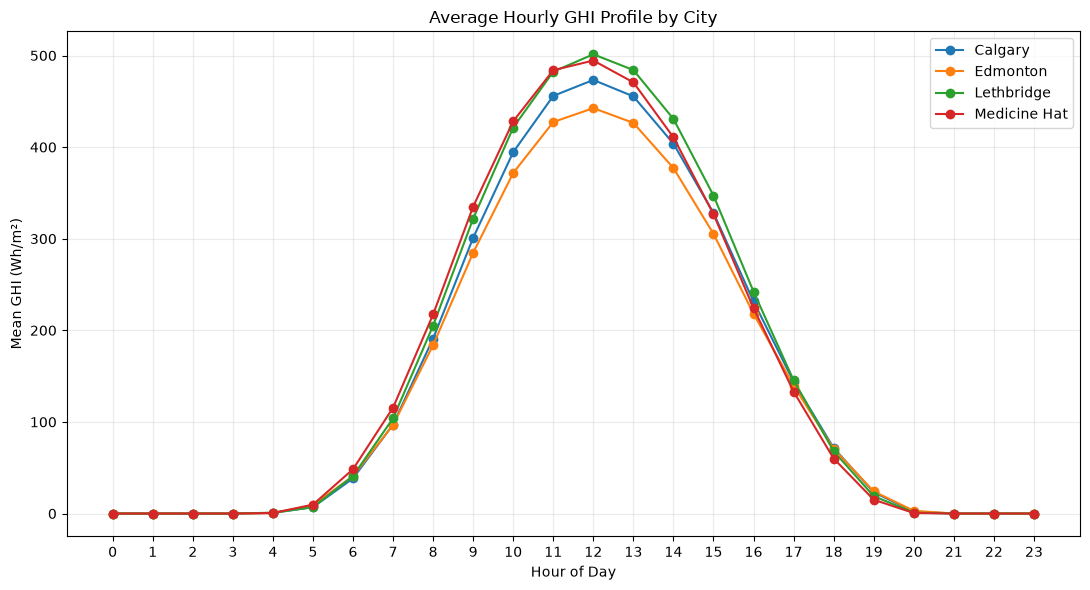

In [20]:
plt.figure(figsize=(11, 6))

for city in hourly_ghi["city"].unique():
    city_hourly = hourly_ghi[
        hourly_ghi["city"] == city
    ]

    plt.plot(
        city_hourly["hour"],
        city_hourly["ghi_wh_m2"],
        marker="o",
        label=city
    )

plt.title("Average Hourly GHI Profile by City")
plt.xlabel("Hour of Day")
plt.ylabel("Mean GHI (Wh/m²)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [21]:
hourly_ghi_pivot = (
    hourly_ghi
    .pivot(
        index="city",
        columns="hour",
        values="ghi_wh_m2"
    )
    .round(2)
)

display(hourly_ghi_pivot)

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
city,,,,,,,,,,,,,,,,,,,,,,,,
Calgary,0.0,0.0,0.0,0.0,0.70,6.88,38.35,97.17,190.97,301.04,394.53,455.93,473.33,455.38,403.76,328.03,231.47,143.83,71.65,23.21,2.19,0.00,0.00,0.00
Edmonton,0.0,0.0,0.0,0.0,0.43,9.07,40.84,96.66,183.89,284.76,371.79,427.40,442.55,426.44,377.12,305.34,218.08,139.52,70.70,24.18,2.98,0.00,0.00,0.00
Lethbridge,0.0,0.0,0.0,0.0,0.92,6.94,40.93,103.93,205.10,321.96,421.40,482.36,501.33,484.12,430.79,347.18,242.21,145.47,68.07,18.97,1.02,0.00,0.00,0.00
Medicine Hat,0.0,0.0,0.0,0.0,0.57,9.73,48.39,115.61,217.38,335.08,428.30,483.98,494.54,470.68,410.71,326.88,224.19,133.17,60.02,15.12,0.55,0.01,0.01,0.01


In [22]:
peak_hour_summary = (
    hourly_ghi.loc[
        hourly_ghi.groupby("city")["ghi_wh_m2"].idxmax()
    ]
    .rename(columns={
        "hour": "peak_hour",
        "ghi_wh_m2": "peak_mean_ghi"
    })
    .reset_index(drop=True)
)

display(peak_hour_summary)

,city,peak_hour,peak_mean_ghi
0,Calgary,12,473.325766
1,Edmonton,12,442.554719
2,Lethbridge,12,501.330253
3,Medicine Hat,12,494.536086


In [23]:
correlation_columns = [
    "ghi_wh_m2",
    "dni_wh_m2",
    "dhi_wh_m2",
    "dry_bulb_temp_c",
    "dew_point_temp_c",
    "wind_speed_ms",
    "station_pressure_pa"
]

correlation_matrix = (
    cweeds[correlation_columns]
    .corr()
    .round(3)
)

display(correlation_matrix)

,ghi_wh_m2,dni_wh_m2,dhi_wh_m2,dry_bulb_temp_c,dew_point_temp_c,wind_speed_ms,station_pressure_pa
ghi_wh_m2,1.000,0.845,0.710,0.497,0.258,0.145,0.012
dni_wh_m2,0.845,1.000,0.377,0.379,0.126,0.115,0.019
dhi_wh_m2,0.710,0.377,1.000,0.383,0.255,0.163,-0.007
dry_bulb_temp_c,0.497,0.379,0.383,1.000,0.877,0.155,-0.073
dew_point_temp_c,0.258,0.126,0.255,0.877,1.000,0.015,-0.031
wind_speed_ms,0.145,0.115,0.163,0.155,0.015,1.000,-0.144
station_pressure_pa,0.012,0.019,-0.007,-0.073,-0.031,-0.144,1.000


In [24]:
city_correlations = []

for city, group in cweeds.groupby("city"):

    correlations = group[
        correlation_columns
    ].corr()["ghi_wh_m2"]

    for variable, value in correlations.items():

        if variable != "ghi_wh_m2":
            city_correlations.append({
                "City": city,
                "Variable": variable,
                "Correlation_with_GHI": round(value, 3)
            })

city_correlation_summary = pd.DataFrame(city_correlations)

display(city_correlation_summary)

,City,Variable,Correlation_with_GHI
0,Calgary,dni_wh_m2,0.832
1,Calgary,dhi_wh_m2,0.707
2,Calgary,dry_bulb_temp_c,0.484
3,Calgary,dew_point_temp_c,0.258
4,Calgary,wind_speed_ms,0.164
5,Calgary,station_pressure_pa,0.071
6,Edmonton,dni_wh_m2,0.835
7,Edmonton,dhi_wh_m2,0.726
8,Edmonton,dry_bulb_temp_c,0.507
9,Edmonton,dew_point_temp_c,0.304


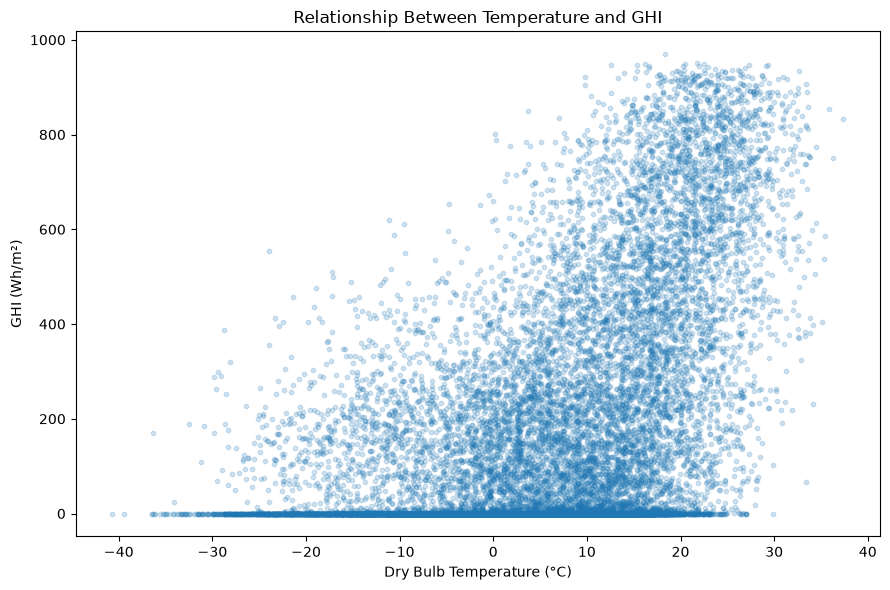

In [25]:
sample = cweeds.sample(
    n=20000,
    random_state=42
)

plt.figure(figsize=(9, 6))

plt.scatter(
    sample["dry_bulb_temp_c"],
    sample["ghi_wh_m2"],
    alpha=0.2,
    s=10
)

plt.title("Relationship Between Temperature and GHI")
plt.xlabel("Dry Bulb Temperature (°C)")
plt.ylabel("GHI (Wh/m²)")

plt.tight_layout()
plt.show()

In [26]:
cweeds["year"] = cweeds["timestamp"].dt.year

annual_ghi = (
    cweeds
    .groupby(["city", "year"])
    .agg(
        mean_ghi=("ghi_wh_m2", "mean"),
        total_ghi=("ghi_wh_m2", "sum")
    )
    .reset_index()
)

display(annual_ghi.head(25))

,city,year,mean_ghi,total_ghi
0,Calgary,1998,152.733606,1.337946e+06
1,Calgary,1999,146.097666,1.279816e+06
2,Calgary,2000,154.051622,1.353189e+06
3,Calgary,2001,155.718639,1.364095e+06
4,Calgary,2002,147.859970,1.295253e+06
5,Calgary,2003,150.900336,1.321887e+06
6,Calgary,2004,144.672732,1.270805e+06
7,Calgary,2005,146.668918,1.284820e+06
8,Calgary,2006,150.286149,1.316507e+06
9,Calgary,2007,148.162576,1.297904e+06


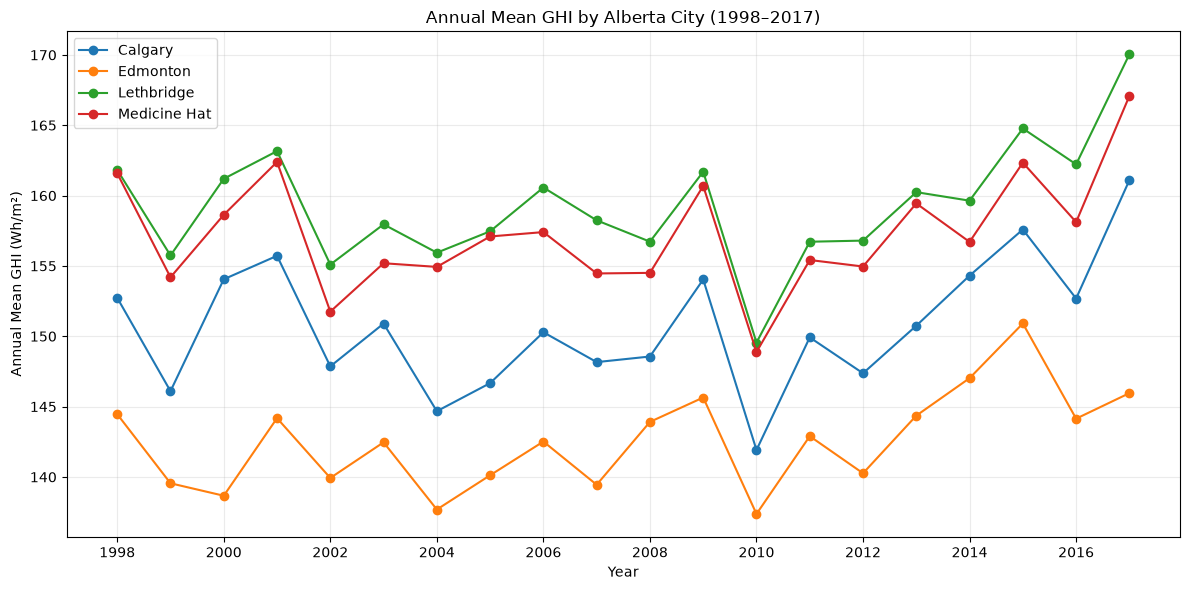

In [27]:
plt.figure(figsize=(12, 6))

for city in annual_ghi["city"].unique():
    temp = annual_ghi[
        annual_ghi["city"] == city
    ]

    plt.plot(
        temp["year"],
        temp["mean_ghi"],
        marker="o",
        label=city
    )

plt.title("Annual Mean GHI by Alberta City (1998–2017)")
plt.xlabel("Year")
plt.ylabel("Annual Mean GHI (Wh/m²)")
plt.xticks(range(1998, 2018, 2))
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [28]:
from scipy.stats import linregress

trend_results = []

for city, group in annual_ghi.groupby("city"):

    result = linregress(
        group["year"],
        group["mean_ghi"]
    )

    trend_results.append({
        "City": city,
        "Slope_per_year": result.slope,
        "Slope_per_decade": result.slope * 10,
        "R_squared": result.rvalue ** 2,
        "P_value": result.pvalue
    })

trend_summary = (
    pd.DataFrame(trend_results)
    .round(4)
)

display(trend_summary)

,City,Slope_per_year,Slope_per_decade,R_squared,P_value
0,Calgary,0.2483,2.4826,0.1010,0.1722
1,Edmonton,0.2952,2.9524,0.2548,0.0232
2,Lethbridge,0.2166,2.1662,0.0893,0.2007
3,Medicine Hat,0.1561,1.5614,0.0490,0.3481


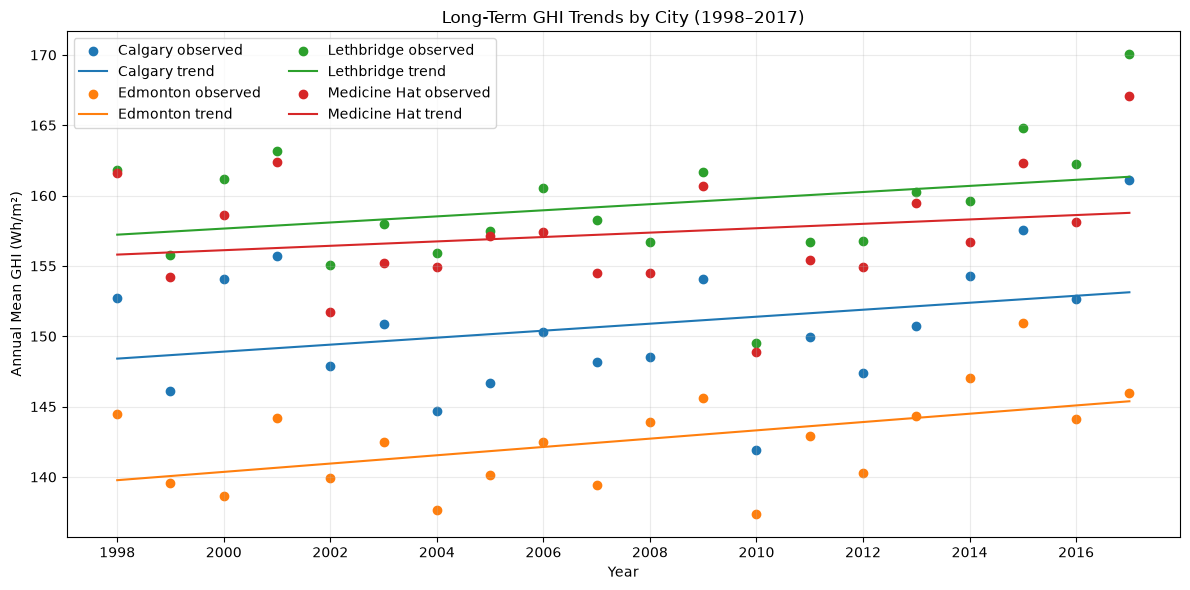

In [30]:
plt.figure(figsize=(12, 6))

for city, group in annual_ghi.groupby("city"):

    plt.scatter(
        group["year"],
        group["mean_ghi"],
        label=f"{city} observed"
    )

    result = linregress(
        group["year"],
        group["mean_ghi"]
    )

    predicted = (
        result.intercept +
        result.slope * group["year"]
    )

    plt.plot(
        group["year"],
        predicted,
        label=f"{city} trend"
    )

plt.title("Long-Term GHI Trends by City (1998–2017)")
plt.xlabel("Year")
plt.ylabel("Annual Mean GHI (Wh/m²)")
plt.xticks(range(1998, 2018, 2))
plt.legend(ncol=2)
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [31]:
seasonal_components = (
    cweeds
    .groupby(["city", "season"])
    .agg(
        mean_ghi=("ghi_wh_m2", "mean"),
        mean_dni=("dni_wh_m2", "mean"),
        mean_dhi=("dhi_wh_m2", "mean")
    )
    .reset_index()
)

season_order = ["Winter", "Spring", "Summer", "Fall"]

seasonal_components["season"] = pd.Categorical(
    seasonal_components["season"],
    categories=season_order,
    ordered=True
)

seasonal_components = seasonal_components.sort_values(
    ["city", "season"]
)

display(seasonal_components.round(2))

,city,season,mean_ghi,mean_dni,mean_dhi
3,Calgary,Winter,58.78,137.70,22.98
1,Calgary,Spring,192.21,203.18,82.80
2,Calgary,Summer,244.62,245.60,90.82
0,Calgary,Fall,105.22,162.97,39.36
7,Edmonton,Winter,48.63,116.67,21.09
5,Edmonton,Spring,187.59,203.30,81.33
6,Edmonton,Summer,238.66,234.68,93.18
4,Edmonton,Fall,93.09,140.26,38.38
11,Lethbridge,Winter,62.06,131.76,25.59
9,Lethbridge,Spring,198.64,211.44,80.82


In [32]:
seasonal_components["dni_dhi_ratio"] = (
    seasonal_components["mean_dni"] /
    seasonal_components["mean_dhi"]
)

display(
    seasonal_components[
        [
            "city",
            "season",
            "mean_dni",
            "mean_dhi",
            "dni_dhi_ratio"
        ]
    ].round(2)
)

,city,season,mean_dni,mean_dhi,dni_dhi_ratio
3,Calgary,Winter,137.70,22.98,5.99
1,Calgary,Spring,203.18,82.80,2.45
2,Calgary,Summer,245.60,90.82,2.70
0,Calgary,Fall,162.97,39.36,4.14
7,Edmonton,Winter,116.67,21.09,5.53
5,Edmonton,Spring,203.30,81.33,2.50
6,Edmonton,Summer,234.68,93.18,2.52
4,Edmonton,Fall,140.26,38.38,3.65
11,Lethbridge,Winter,131.76,25.59,5.15
9,Lethbridge,Spring,211.44,80.82,2.62


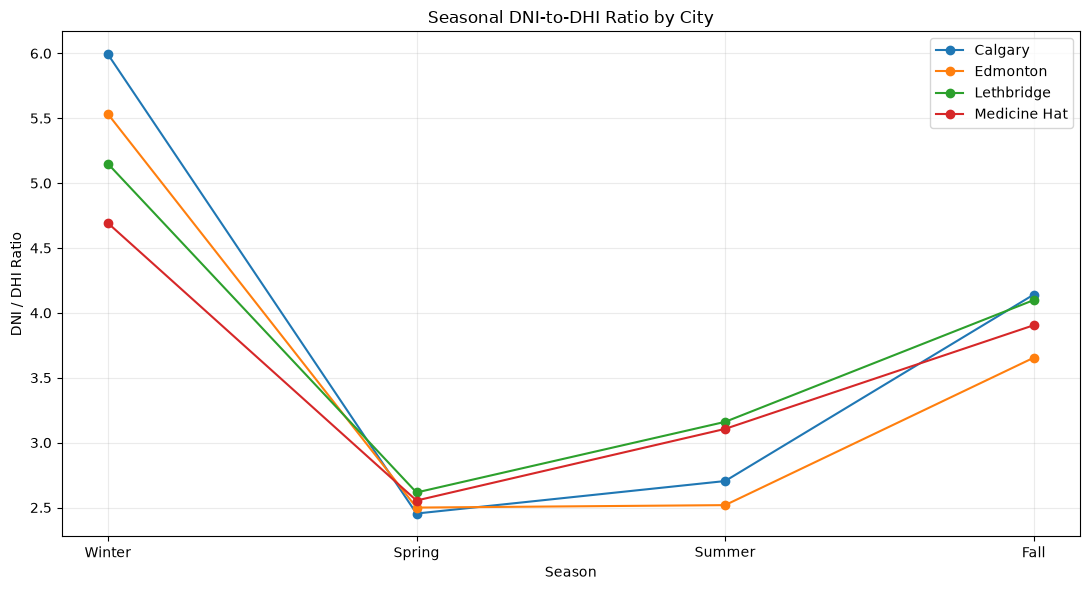

In [33]:
plt.figure(figsize=(11, 6))

for city in seasonal_components["city"].unique():

    temp = seasonal_components[
        seasonal_components["city"] == city
    ]

    plt.plot(
        temp["season"],
        temp["dni_dhi_ratio"],
        marker="o",
        label=city
    )

plt.title("Seasonal DNI-to-DHI Ratio by City")
plt.xlabel("Season")
plt.ylabel("DNI / DHI Ratio")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [34]:
# SAIT valid-hour overview

sait_summary = (
    sait_hourly
    .agg({
        "carport_hourly_wh": ["count", "mean", "median", "std", "min", "max"],
        "rooftop_hourly_wh": ["count", "mean", "median", "std", "min", "max"],
        "total_hourly_wh": ["count", "mean", "median", "std", "min", "max"]
    })
    .round(2)
)

display(sait_summary)

,carport_hourly_wh,rooftop_hourly_wh,total_hourly_wh
count,13423.00,13423.00,13423.00
mean,2227.94,791.51,3019.45
median,44.30,9.50,66.82
std,3548.45,1240.45,4703.64
min,0.00,1.72,2.42
max,14141.83,7004.68,18987.92


In [35]:
sait_hourly["year"] = sait_hourly["timestamp"].dt.year
sait_hourly["month"] = sait_hourly["timestamp"].dt.month
sait_hourly["hour"] = sait_hourly["timestamp"].dt.hour

In [36]:
sait_yearly = (
    sait_hourly
    .groupby("year")
    .agg(
        valid_hours=("timestamp", "size"),
        mean_carport=("carport_hourly_wh", "mean"),
        mean_rooftop=("rooftop_hourly_wh", "mean"),
        mean_total=("total_hourly_wh", "mean")
    )
    .round(2)
    .reset_index()
)

display(sait_yearly)

,year,valid_hours,mean_carport,mean_rooftop,mean_total
0,2019,1650,2710.70,1275.81,3986.51
1,2020,3256,1896.34,740.56,2636.90
2,2021,928,2242.91,1080.28,3323.19
3,2022,1426,644.85,327.79,972.64
4,2023,6163,2637.92,752.59,3390.51


In [37]:
sait_monthly = (
    sait_hourly
    .groupby("month")
    .agg(
        mean_carport=("carport_hourly_wh", "mean"),
        mean_rooftop=("rooftop_hourly_wh", "mean"),
        mean_total=("total_hourly_wh", "mean")
    )
    .reset_index()
)

display(sait_monthly.round(2))

,month,mean_carport,mean_rooftop,mean_total
0,1,713.99,369.20,1083.19
1,2,1137.42,576.58,1714.00
2,3,2409.03,979.94,3388.98
3,4,3255.02,1056.24,4311.26
4,5,3479.01,872.33,4351.34
5,6,3647.64,974.21,4621.85
6,7,3688.76,1046.39,4735.15
7,8,2981.25,1079.49,4060.73
8,9,2295.99,915.00,3210.99
9,10,1151.77,629.50,1781.27


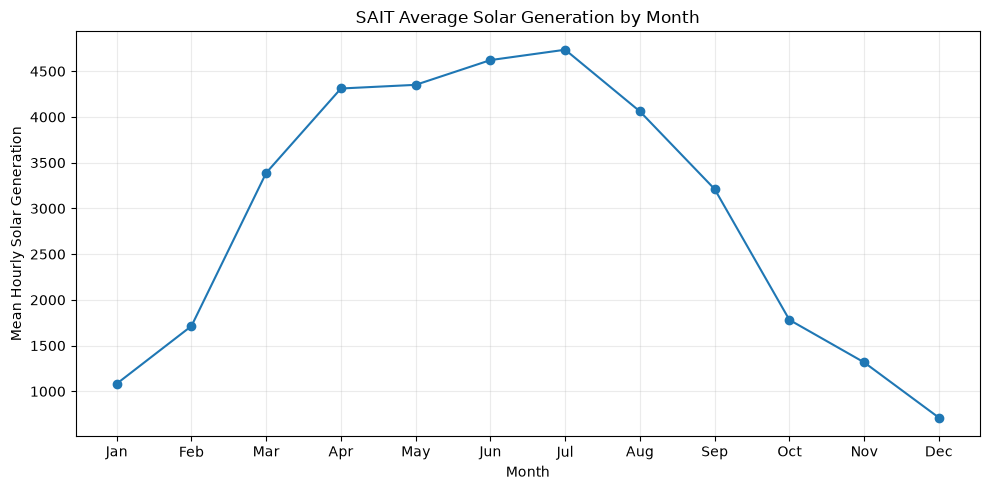

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    sait_monthly["month"],
    sait_monthly["mean_total"],
    marker="o"
)

plt.title("SAIT Average Solar Generation by Month")
plt.xlabel("Month")
plt.ylabel("Mean Hourly Solar Generation")
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [39]:
sait_hourly_profile = (
    sait_hourly
    .groupby("hour")
    .agg(
        mean_carport=("carport_hourly_wh", "mean"),
        mean_rooftop=("rooftop_hourly_wh", "mean"),
        mean_total=("total_hourly_wh", "mean")
    )
    .reset_index()
)

display(sait_hourly_profile.round(2))

,hour,mean_carport,mean_rooftop,mean_total
0,0,14.21,3.86,18.08
1,1,14.25,3.85,18.10
2,2,14.33,3.87,18.20
3,3,14.38,3.87,18.25
4,4,14.37,3.87,18.24
5,5,19.94,4.48,24.43
6,6,125.85,32.64,158.49
7,7,576.49,151.94,728.42
8,8,1627.34,613.00,2240.35
9,9,3270.33,1297.02,4567.35


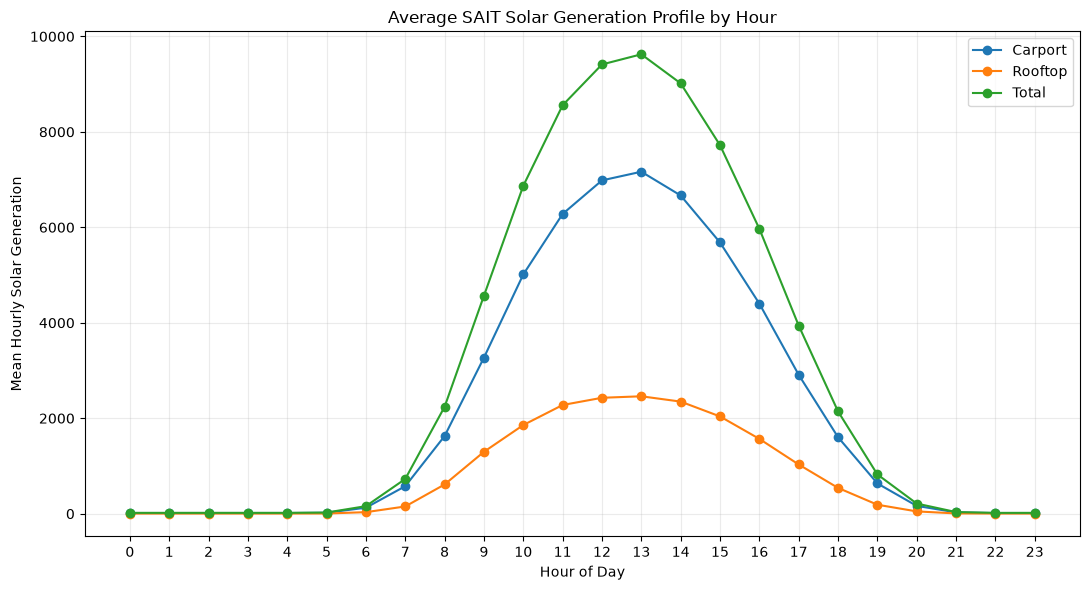

In [40]:
plt.figure(figsize=(11, 6))

plt.plot(
    sait_hourly_profile["hour"],
    sait_hourly_profile["mean_carport"],
    marker="o",
    label="Carport"
)

plt.plot(
    sait_hourly_profile["hour"],
    sait_hourly_profile["mean_rooftop"],
    marker="o",
    label="Rooftop"
)

plt.plot(
    sait_hourly_profile["hour"],
    sait_hourly_profile["mean_total"],
    marker="o",
    label="Total"
)

plt.title("Average SAIT Solar Generation Profile by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Hourly Solar Generation")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [41]:
peak_sait_hour = (
    sait_hourly_profile.loc[
        sait_hourly_profile["mean_total"].idxmax()
    ]
)

display(peak_sait_hour)

hour              13.000000
mean_carport    7164.868476
mean_rooftop    2460.195314
mean_total      9625.063790
Name: 13, dtype: float64

In [42]:
sait_component_summary = (
    sait_hourly
    .agg(
        mean_carport=("carport_hourly_wh", "mean"),
        mean_rooftop=("rooftop_hourly_wh", "mean"),
        mean_total=("total_hourly_wh", "mean")
    )
)

display(sait_component_summary)

,carport_hourly_wh,rooftop_hourly_wh,total_hourly_wh
mean_carport,2227.937349,NaN,NaN
mean_rooftop,NaN,791.511243,NaN
mean_total,NaN,NaN,3019.448592


In [43]:
mean_carport = sait_hourly["carport_hourly_wh"].mean()
mean_rooftop = sait_hourly["rooftop_hourly_wh"].mean()
mean_total = sait_hourly["total_hourly_wh"].mean()

component_share = pd.DataFrame({
    "System": ["Carport", "Rooftop"],
    "Mean_Hourly_Output": [
        mean_carport,
        mean_rooftop
    ],
    "Percent_of_Total": [
        mean_carport / mean_total * 100,
        mean_rooftop / mean_total * 100
    ]
}).round(2)

display(component_share)

,System,Mean_Hourly_Output,Percent_of_Total
0,Carport,2227.94,73.79
1,Rooftop,791.51,26.21


## EDA Summary

The exploratory analysis identified clear geographic, seasonal, temporal, and meteorological patterns in Alberta solar resources.

Across the 1998–2017 CWEEDS period, Lethbridge recorded the highest average GHI, followed closely by Medicine Hat, while Edmonton consistently recorded the lowest values. Mean GHI in Lethbridge was approximately 11.7% higher than Edmonton, supporting the expected north-to-south solar resource gradient.

Solar irradiance showed strong seasonal variation. All four cities reached their highest average GHI during summer and their lowest values during winter. Lethbridge and Medicine Hat maintained the strongest solar resource across most months and seasons.

Hourly analysis showed a consistent diurnal pattern, with GHI increasing through the morning, peaking around 12:00, and declining through the afternoon. Lethbridge recorded the highest average noon GHI, followed by Medicine Hat, Calgary, and Edmonton.

Correlation analysis showed that DNI and DHI were strongly related to GHI, while temperature showed a moderate positive relationship. Wind speed, dew point, and station pressure showed considerably weaker relationships with GHI.

Long-term trend analysis found positive GHI slopes for all four cities between 1998 and 2017. However, only Edmonton showed a statistically significant linear increase at the 5% significance level. Trends for Calgary, Lethbridge, and Medicine Hat were not statistically significant.

The SAIT campus dataset showed a similar seasonal and daily solar-generation pattern to CWEEDS irradiance. Average PV generation increased from winter into summer and peaked during the early afternoon. July produced the highest average monthly generation, while winter months produced the lowest.

The SAIT dataset contains substantial logger outages and uneven year coverage. Therefore, future validation should use only complete hourly observations aligned with overlapping Calgary weather records rather than annual totals.

These findings provide the basis for the feature-engineering and predictive-modeling stages.

In [1]:
import pymannkendall as mk

In [3]:
# Recreate annual GHI summary from cleaned CWEEDS data

import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Users\aduak\Downloads\capstone")
CLEAN_DIR = DATA_DIR / "cleaned"

cweeds = pd.read_csv(
    CLEAN_DIR / "clean_cweeds_4cities.csv",
    parse_dates=["timestamp"],
    low_memory=False
)

cweeds["year"] = cweeds["timestamp"].dt.year

annual_ghi = (
    cweeds
    .groupby(["city", "year"], as_index=False)
    .agg(
        mean_ghi=("ghi_wh_m2", "mean")
    )
)

print("Annual GHI table recreated.")
print("Shape:", annual_ghi.shape)

display(annual_ghi.head(10))

Annual GHI table recreated.
Shape: (80, 3)


,city,year,mean_ghi
0,Calgary,1998,152.733606
1,Calgary,1999,146.097666
2,Calgary,2000,154.051622
3,Calgary,2001,155.718639
4,Calgary,2002,147.859970
5,Calgary,2003,150.900336
6,Calgary,2004,144.672732
7,Calgary,2005,146.668918
8,Calgary,2006,150.286149
9,Calgary,2007,148.162576


In [4]:
mk_results = []

for city, group in annual_ghi.groupby("city"):

    group = group.sort_values("year")

    result = mk.original_test(
        group["mean_ghi"].values
    )

    mk_results.append({
        "City": city,
        "MK_Trend": result.trend,
        "MK_h": result.h,
        "MK_p_value": result.p,
        "MK_z": result.z,
        "Kendall_Tau": result.Tau,
        "Sen_Slope": result.slope
    })

mk_summary = (
    pd.DataFrame(mk_results)
    .round(4)
)

display(mk_summary)

,City,MK_Trend,MK_h,MK_p_value,MK_z,Kendall_Tau,Sen_Slope
0,Calgary,no trend,False,0.1834,1.3302,0.2211,0.3254
1,Edmonton,increasing,True,0.0297,2.1738,0.3579,0.2962
2,Lethbridge,no trend,False,0.2058,1.2653,0.2105,0.1977
3,Medicine Hat,no trend,False,0.2843,1.0707,0.1789,0.1726


In [6]:
from scipy.stats import linregress

trend_results = []

for city, group in annual_ghi.groupby("city"):

    group = group.sort_values("year")

    result = linregress(
        group["year"],
        group["mean_ghi"]
    )

    trend_results.append({
        "City": city,
        "Slope_per_year": result.slope,
        "Slope_per_decade": result.slope * 10,
        "R_squared": result.rvalue ** 2,
        "P_value": result.pvalue
    })

trend_summary = (
    pd.DataFrame(trend_results)
    .round(4)
)

display(trend_summary)

,City,Slope_per_year,Slope_per_decade,R_squared,P_value
0,Calgary,0.2483,2.4826,0.1010,0.1722
1,Edmonton,0.2952,2.9524,0.2548,0.0232
2,Lethbridge,0.2166,2.1662,0.0893,0.2007
3,Medicine Hat,0.1561,1.5614,0.0490,0.3481


In [7]:
trend_final_summary = pd.merge(
    trend_summary,
    mk_summary,
    on="City",
    how="left"
)

display(trend_final_summary)

,City,Slope_per_year,Slope_per_decade,R_squared,P_value,MK_Trend,MK_h,MK_p_value,MK_z,Kendall_Tau,Sen_Slope
0,Calgary,0.2483,2.4826,0.1010,0.1722,no trend,False,0.1834,1.3302,0.2211,0.3254
1,Edmonton,0.2952,2.9524,0.2548,0.0232,increasing,True,0.0297,2.1738,0.3579,0.2962
2,Lethbridge,0.2166,2.1662,0.0893,0.2007,no trend,False,0.2058,1.2653,0.2105,0.1977
3,Medicine Hat,0.1561,1.5614,0.0490,0.3481,no trend,False,0.2843,1.0707,0.1789,0.1726


In [8]:
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

trend_final_summary.to_csv(
    OUTPUT_DIR / "long_term_ghi_trend_analysis.csv",
    index=False
)

print("D5 trend analysis saved.")

D5 trend analysis saved.


In [9]:
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

trend_final_summary.to_csv(
    OUTPUT_DIR / "long_term_ghi_trend_analysis.csv",
    index=False
)

print("D5 trend analysis saved.")

D5 trend analysis saved.


### Between 1998 and 2017, all four cities showed positive estimated GHI slopes; however, only Edmonton exhibited statistically significant evidence of an increasing long-term trend. Edmonton increased by approximately 2.95 Wh/m² per decade according to linear regression (p = 0.0232), while the Mann–Kendall test independently confirmed a significant increasing monotonic trend (p = 0.0297). Calgary, Lethbridge, and Medicine Hat showed no statistically significant long-term trend.###